<a href="https://colab.research.google.com/github/pablojbec/Analisis_Estadistico_Telecomunicaciones/blob/main/Analisis_correlacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción


El objetivo de este análsis es identificar los factores de comportamiento del cliente que están mas fuertemente asociados con el ingreso anual generado para una plataforma de comercio electrónico en Latinoamérica con millones de usuarios


## 1. Carga y exploración del dataset

En esta sección se valida que el dataset se cargue correctamente, que los tipos de datos en cada columna seán coherentes y se manejan los valores faltantes.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
from matplotlib.colors import LinearSegmentedColormap

### Cargar Dataset

In [13]:
# Cargar el dataset y explorar datos
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Datasets/3. Análisis_Correlacional/novaretail_comportamiento_clientes_2024.csv")

df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [10]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## 2. Prepararación de datos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  

Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [14]:
# verificación de cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Exploraración de variables numéricas

In [15]:
# Estadísticas descriptivas de variables numéricas
columnas_num=['edad','nivel_ingreso', 'visitas_mes','compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[columnas_num].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` — se distribuye simétricamente, con rango de edad de clientes entre 18 y 75 años. La mayoria de los clientes tiene entre los 26 y los 50 años.
- `nivel_ingreso` - se distribuye simétricamente, el ingreso anual estimado del cliente varia entre 8000 y 74791.
- `visitas_mes` - se distribuye simétricamente, en promedio los clientes visitaron 10 veces al mes el comercio en 2024
- `compras_mes` - se distribuye simétricamente, en promedio los clientes hicieron una compra al mes en 2024.
- `gasto_publicidad_dirigida` - Se distribuye simétricamente, en promedio el gasto en publicidad dirigida que necesita un cliente de NovaRetail+ en 2024 es de 20,14.
- `satisfacción` - se distribuye simetricamente, en promedio el nivel se satisfacción general del cliente es 3.6, moderadamente alto para NovaRetail+.
- `ingreso_anual` - se distribuye simeticamente, en promedio el ingreso generado por un cliente de NovaRetail+ en 2024 es de 34,48.

#### Exploraración de variables binarias

In [16]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_bi=['miembro_premium', 'abandono']
df[columnas_bi].nunique()

,0
miembro_premium,2
abandono,2


Diagnóstico inicial de variables binarias

- `miembro_premium` — Los valores consignados en la columna son coherentes.
- `abandono` — Los valores consignados en la columna son coherentes.

#### Exploraración de variables categóricas

In [17]:
# Verificar el número de valores únicos por variable categórica
columnas_cat=['id_cliente', 'tipo_dispositivo', 'region']
df[columnas_cat].nunique()

,0
id_cliente,15000
tipo_dispositivo,3
region,4


In [19]:
# Explorar variables categóricas y cómo se distribuyen
df[columnas_cat].describe()

,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-114999,móvil,norte
freq,1,9818,4395


Diagnóstico inicial de variables categóricas

- `id_cliente` — Los datos consignados en la columna se encuentra satisfactoriamente consignados ya que ninguno se repite.
- `tipo_dispositivo` — los clientes visitan el comercio eléctrónico con más frecuencia a través de dispositivos móviles.
- `region` — la región en la que más posee clientes de el comercio electrónico es la norte.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## 3. Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

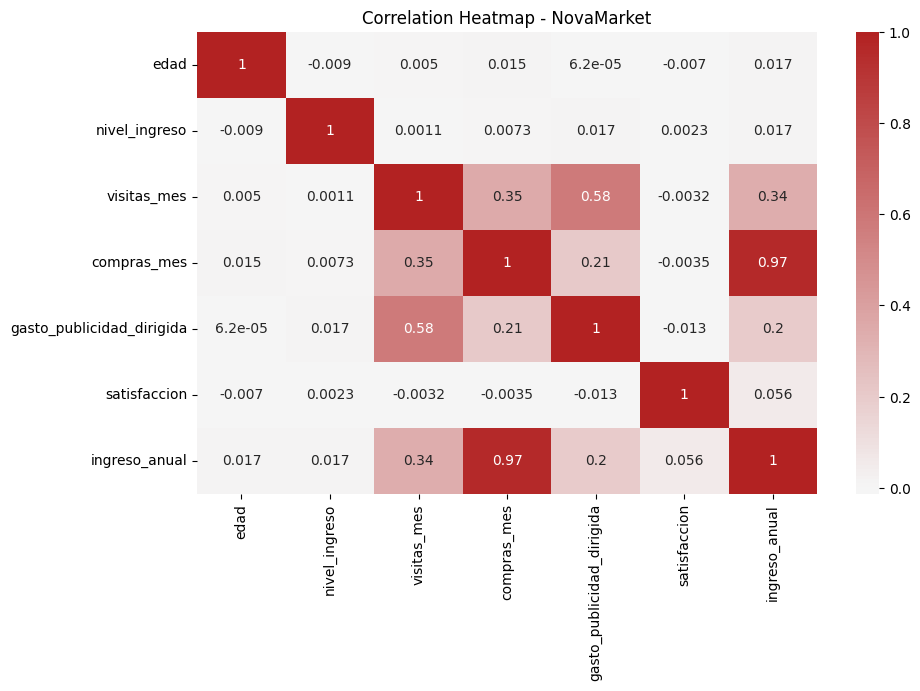

In [20]:
# Visualizar la matriz de correlación para identificar relaciones
# matriz de correlación
df_corr = df[columnas_num].corr()

# crear paleta de colores
custom_cmap = LinearSegmentedColormap.from_list("TT_colors", ["azure", "whitesmoke", "firebrick"])
# crear heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap=custom_cmap, center=0)
plt.title("Correlation Heatmap - NovaMarket")
plt.show()

Observaciones generales (Heatmap)  
- Se observa una relación positiva moderada (0.58) entre las variables gasto_publicidad_dirigida y visitas_mes.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general, para lo cual se concluye:

  - No es conveniente presentar un scatterplot general puesto que muchas de las correlaciones son prácticamente nulas, por lo cual el presente reporte se llenaria de gráficos poco informativos los cuales podrian hacerlo ver redundante y visualmente saturado.

### Scatterplot para pares clave

#### 1️⃣compras_mes vs ingreso_anual

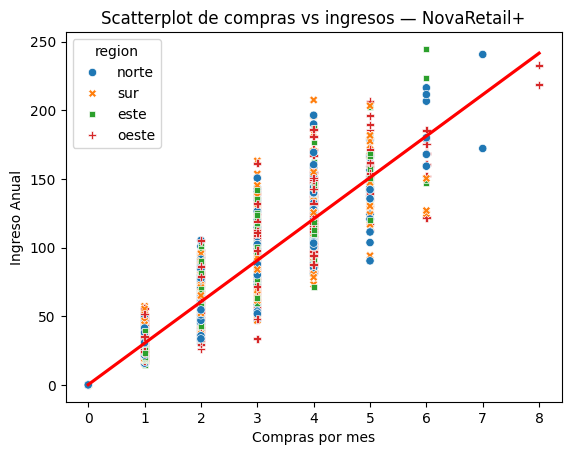

In [21]:
# Visualización
sns.scatterplot(
    data=df, x="compras_mes", y="ingreso_anual",
    hue="region",
    style="region")
sns.regplot(data=df, x="compras_mes", y="ingreso_anual",
    scatter=False, color='red')

plt.title("Scatterplot de compras vs ingresos — NovaRetail+")
plt.xlabel("Compras por mes")
plt.ylabel("Ingreso Anual")
plt.show()

#### 2️⃣visitas_mes vs ingreso_anual

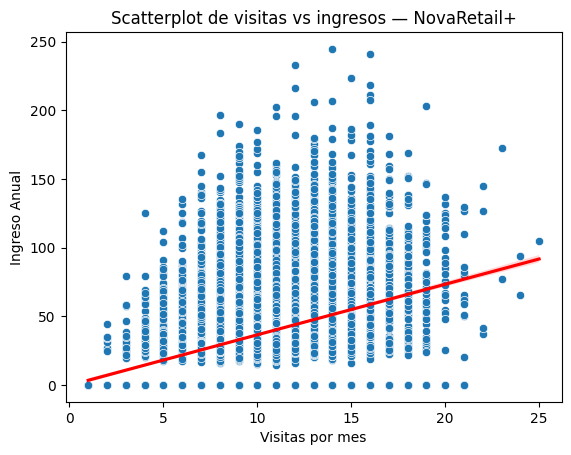

In [22]:
# Visualización
sns.scatterplot(data=df, x="visitas_mes", y="ingreso_anual")
sns.regplot(data=df, x="visitas_mes", y="ingreso_anual",
    scatter=False, color='red')

plt.title("Scatterplot de visitas vs ingresos — NovaRetail+")
plt.xlabel("Visitas por mes")
plt.ylabel("Ingreso Anual")
plt.show()

#### 3️⃣ visitas_mes vs compras_mes

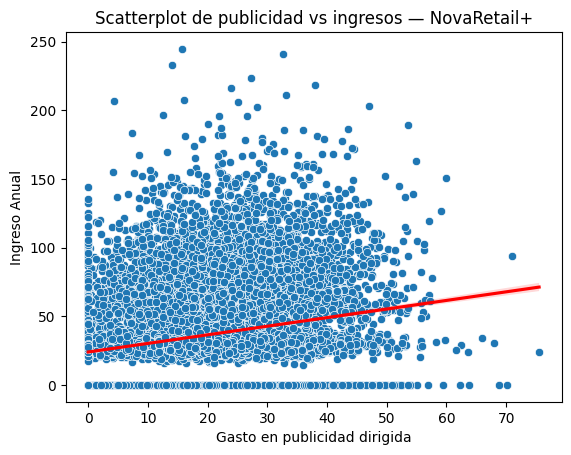

In [23]:
# Visualización
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="ingreso_anual")
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="ingreso_anual",
    scatter=False, color='red')

plt.title("Scatterplot de publicidad vs ingresos — NovaRetail+")
plt.xlabel("Gasto en publicidad dirigida")
plt.ylabel("Ingreso Anual")
plt.show()

Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Se observa una relación positiva muy fuerte entre compras_mes e ingreso_anual: a medida que aumenta la cantidad de compras mensuales, también aumenta el ingreso anual generado por el cliente.
- Los datos presentan una dispersión relativamente baja alrededor de la línea de tendencia, lo que indica un patrón consistente entre ambas variables.
- No se identifican clusters claramente diferenciados; la mayoría de las observaciones siguen una misma tendencia general.
- La relación parece predominantemente lineal, lo cual es coherente con el alto coeficiente de correlación obtenido (r = 0.967).
- Este comportamiento sugiere una posible colinealidad o redundancia parcial entre ambas variables dentro del análisis.

**visitas_mes vs ingreso_anual**
- Se evidencia una relación positiva débil a moderada entre visitas_mes e ingreso_anual, con una ligera tendencia ascendente.
- La dispersión de los datos es alta, lo que indica que clientes con un número similar de visitas pueden generar niveles de ingreso muy diferentes.
- No se observan clusters claramente definidos, aunque existen algunos grupos dispersos de clientes con ingresos altos y frecuencia de visitas moderada.
- La relación parece aproximadamente lineal, pero con baja capacidad explicativa debido a la variabilidad observada.
- Esto sugiere que la frecuencia de visitas, por sí sola, no es suficiente para explicar el comportamiento de ingreso de los clientes.

**gasto_publicidad_dirigida vs ingreso_anual**
- Se observa una relación positiva muy débil entre gasto_publicidad_dirigida e ingreso_anual.
- Los puntos presentan una dispersión elevada y no siguen un patrón claramente concentrado, lo que evidencia una asociación limitada entre ambas variables.
- No se identifican clusters relevantes ni segmentos claramente diferenciados.
- La relación aparenta ser lineal, aunque extremadamente tenue, con una pendiente pequeña en la línea de tendencia.
- Esto indica que el gasto en publicidad dirigida no muestra una asociación fuerte con el ingreso anual dentro de este conjunto de datos.

## 4. Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [24]:
# Calcular correlación entre variables relevantes
#Para correlaciones numéricas
columnas_corr=['visitas_mes','compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual']
def corr_numerica(df, columnas, metodo="pearson"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")
corr_numerica(df, columnas_corr, metodo="pearson")

,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual
visitas_mes,1.000000,0.353844,0.578947,0.337147
compras_mes,0.353844,1.000000,0.207528,0.967149
gasto_publicidad_dirigida,0.578947,0.207528,1.000000,0.197483
ingreso_anual,0.337147,0.967149,0.197483,1.000000


Observaciones de correlación

**compras_mes e ingreso_anual**
- Presentan una correlación positiva muy fuerte (r = 0.967). Esto indica que, a mayor ingreso anual, tiende a aumentar significativamente la cantidad de compras mensuales.
  
**visitas_mes y gasto_publicidad_dirigida**
- Tienen una correlación positiva moderada (r = 0.579). Esto sugiere que un mayor gasto en publicidad dirigida está asociado con un incremento en las visitas mensuales.

**visitas_mes y compras_mes**
- Muestran una correlación positiva débil a moderada (r = 0.354). Aunque existe cierta relación entre visitar y comprar, no es especialmente fuerte.

**visitas_mes e ingreso_anual**
- Presentan una correlación positiva débil (r = 0.337), lo que indica que el nivel de ingresos tiene poca influencia lineal sobre la cantidad de visitas.
  
**compras_mes y gasto_publicidad_dirigida**
- Tienen una correlación positiva débil (r = 0.208), sugiriendo que la publicidad no impacta directamente de forma fuerte en las compras.
  
**gasto_publicidad_dirigida e ingreso_anual**
- Muestran una correlación positiva muy débil (r = 0.197), indicando prácticamente ausencia de relación lineal relevante entre ambas variables.

**Nota:** La correlación de Spearman mostró resultados muy similares, confirmando la estabilidad de las relaciones observadas.

### Punto-biserial

In [25]:

# Calcular correlación entre variables relevantes

pb,_ = pointbiserialr(df["miembro_premium"],df["ingreso_anual"])
print("Correlación entre: tipo de suscripcion e ingresos anuales")
print(f"Punto-biserial: {pb:.3f}")



Correlación entre: tipo de suscripcion e ingresos anuales
Punto-biserial: 0.093


In [26]:
# Calcular correlación entre variables relevantes
pb,_ = pointbiserialr(df["abandono"],df["satisfaccion"])
print("Correlación entre: abandono y saisfacción del cliente")
print(f"Punto-biserial: {pb:.3f}")

Correlación entre: abandono y saisfacción del cliente
Punto-biserial: -0.024


#### Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación debil (r = 0.0931). Sin embargo, esto sugiere que los clientes m que generan mayores ingresos presentan una ligera tendencia a pertenecer al programa premium, pero la relación no es suficientemente fuerte como para considerarse relevante desde el punto de vista práctico.

**abandono vs satisfaccion**
- Relación debil (r = -0.0238), indicando que niveles ligeramente mayores de satisfacción podrían asociarse con una menor probabilidad de abandono.

**Nota:** las demás variables presentaron correlaciones cercanas a cero, por lo que no se evidencian relaciones relevantes.

### V de Cramér

In [28]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v

In [29]:
# Aplicar V de Cramér en variables relevantes

cramer_v(df, "tipo_dispositivo", "region")

np.float64(0.012378338407739397)

**Observaciones V de Cramér**

*tipo_dispositivo* y *region*
- La correlacion de 0.013 entre la variables, indica una relacion debil entre las dos variables, lo que indica que la distribución de tipos de dispositivo es casi igual en todas las regiones.

## 5. Interpretación de resultados para el negocio

### Hallazgo 1 — Las compras mensuales son el factor más asociado con el ingreso anual

**Evidencia visual:**   
El scatterplot entre compras_mes e ingreso_anual muestra una tendencia ascendente clara y una baja dispersión alrededor de la línea de regresión.

**Evidencia numérica:**
La correlación de Pearson entre ambas variables es muy alta (r = 0.967), siendo la asociación más fuerte encontrada en el análisis.
**Interpretación**  
Los clientes que realizan más compras mensuales tienden a generar mayores ingresos anuales para NovaRetail+. La relación observada es consistente y estable dentro del conjunto de datos analizado.

**No podemos afirmar**  
No podemos concluir que aumentar artificialmente la cantidad de compras cause directamente un incremento del ingreso anual. Ambas variables podrían estar influenciadas por otros factores no incluidos en el análisis, como nivel socioeconómico, fidelización o hábitos de consumo.

**Implicación de negocio**  
La frecuencia de compra puede utilizarse como un indicador relevante para segmentar clientes de alto valor y priorizar estrategias de retención, programas de fidelización y campañas de recompra.

### Hallazgo 2 — La publicidad dirigida se relaciona más con las visitas que con el ingreso

**Evidencia visual:**  
El scatterplot entre gasto_publicidad_dirigida y ingreso_anual presenta una tendencia apenas perceptible y una alta dispersión de los datos.

**Evidencia numérica:**
La correlación entre gasto_publicidad_dirigida e ingreso_anual es muy débil (r = 0.197), mientras que la correlación entre gasto_publicidad_dirigida y visitas_mes es moderada (r = 0.579).

**Interpretación**  
La publicidad dirigida parece estar más asociada con el aumento de tráfico o visitas a la plataforma que con la generación directa de ingresos.

**No podemos afirmar**  
No podemos asegurar que incrementar el gasto publicitario aumente las ventas o ingresos anuales, ya que el análisis únicamente identifica asociaciones y no relaciones causales.

**Implicación de negocio**  
NovaRetail+ podría evaluar la efectividad de sus campañas no solo por visitas generadas, sino también por métricas de conversión y rentabilidad, con el fin de optimizar el retorno de inversión publicitaria.

### Hallazgo 3 — Las visitas no garantizan mayores ingresos

**Evidencia visual:**  
El scatterplot entre visitas_mes e ingreso_anual muestra una tendencia positiva ligera, pero con una dispersión considerable.

**Evidencia numérica:**
La correlación entre ambas variables es débil (r = 0.337).

**Interpretación**  
Aunque existe cierta asociación entre visitar más la plataforma y generar mayores ingresos, la relación no es suficientemente fuerte como para considerar las visitas como un predictor confiable del valor económico del cliente.

**No podemos afirmar**  
No podemos concluir que aumentar el tráfico de usuarios produzca automáticamente mayores ingresos o compras efectivas.

**Implicación de negocio**  
Las estrategias de crecimiento no deberían enfocarse únicamente en aumentar visitas, sino también en mejorar conversión, experiencia de usuario y recurrencia de compra.

## 6. Limitaciones y próximos pasos

### **Limitaciones**
- El análisis realizado es exclusivamente correlacional; por lo tanto, las relaciones identificadas no implican causalidad.
- Algunas variables presentan relaciones lineales débiles, lo que limita su capacidad explicativa individual.
- No se evaluaron variables externas que podrían influir en el ingreso anual, como promociones, historial de fidelización, competencia o comportamiento estacional.
- El análisis se basa en un único conjunto de datos correspondiente al periodo evaluado(2024), por lo que los patrones podrían cambiar en otros contextos o periodos de tiempo.
- La presencia de posibles variables redundantes o colineales puede afectar interpretaciones posteriores en modelos predictivos.

### **Próximos pasos**

- Evaluar técnicas de segmentación para identificar perfiles de clientes de alto valor.
- Analizar métricas de conversión para entender qué porcentaje de visitas termina efectivamente en compras.
- Incorporar variables temporales y comportamentales adicionales para enriquecer el análisis.
- Evaluar posibles problemas de colinealidad antes de desarrollar modelos de machine learning o regresión.
- Realizar análisis experimentales o pruebas A/B que permitan validar relaciones causales entre publicidad, visitas y compras.
- Construir modelos predictivos que permitan estimar el ingreso anual a partir del comportamiento del cliente.